In [1]:
'''
Clone github and pip install skorch if working in colab
'''

import os

try:
    import google.colab
    os.system('git clone https://github.com/ethanresek/luminal-classifiers 2>/dev/null; cd /content/luminal-classifiers && git pull')
    os.system('pip install skorch')
except ImportError:
    pass

In [2]:
import numpy as np
import pandas as pd
import sys
import joblib
import torch.nn.functional as F

from datetime import datetime
from torch import nn, ones, sigmoid, optim
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance
from skorch import NeuralNetBinaryClassifier
from skorch.callbacks import EarlyStopping
from sklearn.metrics import f1_score, roc_auc_score, balanced_accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Imports OK")
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

Imports OK


In [3]:
FEATURE_COUNTS = [5, 10, 20, 30, 40, 50]
ALL_SIZES = FEATURE_COUNTS + [489]
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
'''
Split set up instructions for local vs colab running
'''
try:
    from google.colab import drive
    sys.path.append('/content/luminal-classifiers')
    from pre_process import preprocess, split_data

    # Change CSV path if necessary
    # '/content/luminal-classifiers/' should remain the start of the path
    CSV = '/content/luminal-classifiers/data/METABRIC_RNA_Mutation.csv'
    print('Working in Colab')
except ImportError:
    from pre_process import preprocess, split_data

    # Change CSV to path in local storage if needed
    CSV = 'data/METABRIC_RNA_Mutation.csv'
    print('Working locally')

Working in Colab


In [5]:
DF = pd.read_csv(CSV, low_memory=False)

# Specify which columns to keep from dataframe
Y_OLD_NAME = 'pam50_+_claudin-low_subtype'
KEEP = list(DF.columns[31:520]) + [Y_OLD_NAME]

# Split data and convert to float32 for Torch
X, y = preprocess(DF, KEEP)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=RANDOM_SEED)
X_train, X_test, y_train, y_test = X_train.astype('float32').values, X_test.astype('float32').values, y_train.astype('float32').values, y_test.astype('float32').values

In [6]:
class SparsityNNBC(NeuralNetBinaryClassifier):
    '''
    Override NNBC model's get_loss model to apply sparsity effect to the loss.
    '''
    def __init__(self, **kwargs):
        super(SparsityNNBC, self).__init__(**kwargs)

    def get_loss(self, y_pred, y_true, X=None, training=False):
        sparsity_effect = self.module_.sparsity * sigmoid(self.module_.gate).sum()
        loss = super(SparsityNNBC, self).get_loss(y_pred, y_true, X, training) + sparsity_effect
        return loss

In [7]:
class MLP(nn.Module):
    '''
    Simple multi-layer perceptron model for classifying Luminal A/B breast cancer. Uses ReLu as an activation function for each layer.

    Inputs:
    sparsity - A penalty that is used to hit specific feature counts (relevant for feature selection in CS6140_MLP_Features)
    hidden_sizes - The size of each hidden layer
    dropout - probability that dropout is applied to elements


    Architecture:
    gate - A learnable parameter that can "shut off" specific features that are less important for cancer classification
    linear - Applies a linear transformation to input; standard to feed forward networks
    batch normalize - normalize layer outputs to have zero mean and unit variance
    '''

    def __init__(self, hidden_sizes, dropout, sparsity, input_size=489, output_size=1):
        super(MLP, self).__init__()

        self.sparsity = sparsity
        self.gate = nn.Parameter(ones(input_size))

        sizes = [input_size] + hidden_sizes + [output_size]
        self.linears = nn.ModuleList([
            nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes) - 1)
        ])
        self.dropout = nn.Dropout(dropout)
        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(h) for h in hidden_sizes
        ])

    def forward(self, x):
        '''

        :param x: input data
        :return: output results
        '''

        x = x * sigmoid(self.gate)

        for i, l in enumerate(self.linears[:-1]):
            x = l(x)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = self.dropout(x)

        x = self.linears[-1](x)

        return x

In [8]:
# Set up DNN trainer with basic starter values so initial hyperparameter selection runs smoothly at beginning.
net = SparsityNNBC(
    module=MLP,
    criterion=nn.BCEWithLogitsLoss,
    optimizer=optim.Adam,
    max_epochs=100,
    callbacks=[EarlyStopping(patience=10)],
    module__hidden_sizes=[128, 64],
    module__dropout=0.3,
    module__input_size=489,
    module__sparsity=1e-3,
    optimizer__weight_decay=1e-3,
    verbose=0
)

# Distribution of possible values for hyperparameters
p_dist = {
    'module__hidden_sizes': [[256, 128], [128, 64], [64, 32], [128]],
    'module__dropout': [0.1, 0.2, 0.3, 0.4, 0.5],
    'module__sparsity': [1e-4, 1e-3, 5e-3, 1e-2],
    'optimizer__weight_decay': [1e-4, 1e-3, 1e-2],
    'lr': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
    'batch_size': [16, 32, 64],
}

In [9]:
results = {}

# Run randomized search to find optimal hyperparameters
rand_search = RandomizedSearchCV(net, param_distributions=p_dist, scoring='f1', n_iter=100, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED), random_state=RANDOM_SEED, n_jobs=-1)
rand_search.fit(X_train, y_train)
print(rand_search.best_params_)

# For time purposes, GridSearch was not run on the Base model

{'optimizer__weight_decay': 0.0001, 'module__sparsity': 0.0001, 'module__hidden_sizes': [128], 'module__dropout': 0.1, 'lr': 0.0001, 'batch_size': 32}


In [10]:
# Produce F1, Balanced Accuracy, and ROC AUC scores

final_net = rand_search.best_estimator_

y_pred = final_net.predict(X_test)
y_pred_prob = final_net.predict_proba(X_test)[:, 1]

print('F1:', f1_score(y_test, y_pred))
print('Balanced Accuracy:', balanced_accuracy_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_pred_prob))


F1: 0.883495145631068
Balanced Accuracy: 0.8493661971830986
ROC AUC: 0.9422535211267606


In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
base_fold_metrics = []
base_params = rand_search.best_params_

for train_idx, val_idx in skf.split(X_train, y_train):
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    fold_net = SparsityNNBC(
        module=MLP,
        criterion=nn.BCEWithLogitsLoss,
        optimizer=optim.Adam,
        max_epochs=100,
        callbacks=[EarlyStopping(patience=10)],
        module__input_size=489,
        verbose=0,
        **base_params
    )
    fold_net.fit(X_fold_train, y_fold_train)

    y_pred = fold_net.predict(X_fold_val)
    y_pred_prob = fold_net.predict_proba(X_fold_val)[:, 1]

    base_fold_metrics.append({
        'f1': f1_score(y_fold_val, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_fold_val, y_pred),
        'roc_auc': roc_auc_score(y_fold_val, y_pred_prob),
        'y_true': y_fold_val,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob,
    })

results[489] = base_fold_metrics

In [12]:
# Store timestamped results of RandomizedSearch and input data sets
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
os.makedirs('models', exist_ok=True)

joblib.dump({
    'model': rand_search,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}, f'models/tuned_MLP_search_{timestamp}.joblib')

['models/tuned_MLP_search_20260424_191855.joblib']

In [13]:
'''
Use permutation importance from base model for feature extraction
'''
perm_result = permutation_importance(final_net, X_test, y_test, n_repeats=30, scoring='f1', random_state=RANDOM_SEED)
importances = perm_result.importances_mean
feature_names = X.columns
all_top_k_idx = []

for k in FEATURE_COUNTS:
    top_k_idx = np.argsort(importances)[-k:]
    all_top_k_idx.append(top_k_idx)
    top_k_names = feature_names[top_k_idx]
    print(f"Top {k}: {list(top_k_names)}")

Top 5: ['cyp3a43', 'hist1h2bc', 'cdk1', 'cacna2d3', 'tubb4b']
Top 10: ['mmp7', 'lfng', 'ros1', 'ar', 'srd5a3', 'cyp3a43', 'hist1h2bc', 'cdk1', 'cacna2d3', 'tubb4b']
Top 20: ['msh2', 'hsd17b8', 'dtx3', 'bbc3', 'dnah2', 'tsc2', 'cyp11b2', 'mmp1', 'tgfb2', 'clrn2', 'mmp7', 'lfng', 'ros1', 'ar', 'srd5a3', 'cyp3a43', 'hist1h2bc', 'cdk1', 'cacna2d3', 'tubb4b']
Top 30: ['cdk4', 'casp3', 'adam10', 'mmp28', 'pdgfa', 'smad4', 'mmp14', 'e2f4', 'nfkb2', 'ryr2', 'msh2', 'hsd17b8', 'dtx3', 'bbc3', 'dnah2', 'tsc2', 'cyp11b2', 'mmp1', 'tgfb2', 'clrn2', 'mmp7', 'lfng', 'ros1', 'ar', 'srd5a3', 'cyp3a43', 'hist1h2bc', 'cdk1', 'cacna2d3', 'tubb4b']
Top 40: ['myh9', 'cyp2c8', 'tbx3', 'ptprm', 'fbxw7', 'twist1', 'prkacg', 'epcam', 'eif4e', 'rpgr', 'cdk4', 'casp3', 'adam10', 'mmp28', 'pdgfa', 'smad4', 'mmp14', 'e2f4', 'nfkb2', 'ryr2', 'msh2', 'hsd17b8', 'dtx3', 'bbc3', 'dnah2', 'tsc2', 'cyp11b2', 'mmp1', 'tgfb2', 'clrn2', 'mmp7', 'lfng', 'ros1', 'ar', 'srd5a3', 'cyp3a43', 'hist1h2bc', 'cdk1', 'cacna2d3', 'tu

In [14]:
'''
Run randomized search on given number of features
'''
searches = []

for arr in all_top_k_idx:
    print("------------------------------------------------------")
    print(f"Searching for hyperparameters for {len(arr)} features")
    print("------------------------------------------------------")
    X_train_k = X_train[:, arr]
    X_test_k = X_test[:, arr]

    # Set up DNN trainer with basic starter values so initial hyperparameter selection runs smoothly at beginning.
    net = SparsityNNBC(
        module=MLP,
        criterion=nn.BCEWithLogitsLoss,
        optimizer=optim.Adam,
        max_epochs=100,
        callbacks=[EarlyStopping(patience=10)],
        module__hidden_sizes=[128, 64],
        module__dropout=0.3,
        module__input_size=len(arr),
        module__sparsity=1e-3,
        optimizer__weight_decay=1e-3,
        verbose=0
    )

    # Distribution of possible values for hyperparameters
    p_dist = {
        'module__hidden_sizes': [[256, 128], [128, 64], [64, 32], [128]],
        'module__dropout': [0.1, 0.2, 0.3, 0.4, 0.5],
        'module__sparsity': [1e-4, 1e-3, 5e-3, 1e-2],
        'optimizer__weight_decay': [1e-4, 1e-3, 1e-2],
        'lr': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
        'batch_size': [16, 32, 64],
    }

    # Run randomized search to find range for hyperparameters
    rand_search = RandomizedSearchCV(net, param_distributions=p_dist, scoring='f1', n_iter=100, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED), random_state=RANDOM_SEED, n_jobs=-1)
    rand_search.fit(X_train_k, y_train)

    y_pred = rand_search.predict(X_test_k)
    y_pred_prob = rand_search.predict_proba(X_test_k)[:, 1]

    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

    # Report accuracy scores for randomized search
    print("Accuracies for Randomized Search CV")
    print(f"F1-score: {f1}")
    print(f"ROC-AUC: {roc_auc}")
    print(f"Balanced Accuracy: {balanced_accuracy}")

    best = rand_search.best_params_

    # Create new ranges for possible hyperparameter values based on step sizes
    # Parameters with no natural step size are kept as is
    grid_params = {}
    for key, val in best.items():
        if (isinstance(val, str)
                or val is None
                or key == 'module__hidden_sizes'
                or key == 'batch_size'):
            grid_params[key] = [val]
        elif isinstance(val, int):
            step = max(1, round(0.1 * val))
            grid_params[key] = [max(1, val - step), val, val + step]
        elif isinstance(val, float):
            step = max(0.005, round(0.1 * val, 4))
            grid_params[key] = [max(0, round(val - step, 4)), val, val + step]

    post_rand_net = rand_search.best_estimator_

    # Run GridSearch for thorough examination of hyperparameters
    grid_search = GridSearchCV(post_rand_net, param_grid=grid_params, scoring='f1', cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED), n_jobs=-1)
    grid_search.fit(X_train_k, y_train)

    best_net = grid_search.best_estimator_
    best_params = grid_search.best_params_

    # Retrain model with different validation splits to compute means and standard deviations
    # Used for plotting data later
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    fold_metrics = []

    for train_idx, val_idx in skf.split(X_train_k, y_train):
        X_fold_train, X_fold_val = X_train_k[train_idx], X_train_k[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        fold_net = SparsityNNBC(
            module=MLP,
            criterion=nn.BCEWithLogitsLoss,
            optimizer=optim.Adam,
            max_epochs=100,
            callbacks=[EarlyStopping(patience=10)],
            module__input_size=len(arr),
            verbose=0,
            **best_params
        )
        fold_net.fit(X_fold_train, y_fold_train)

        y_pred = fold_net.predict(X_fold_val)
        y_pred_prob = fold_net.predict_proba(X_fold_val)[:, 1]

        fold_metrics.append({
            'f1': f1_score(y_fold_val, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_fold_val, y_pred),
            'roc_auc': roc_auc_score(y_fold_val, y_pred_prob),
            'y_true': y_fold_val,
            'y_pred': y_pred,
            'y_pred_prob': y_pred_prob,
        })

    results[len(arr)] = fold_metrics

    # Produce F1, Balanced Accuracy, and ROC AUC scores
    y_pred = grid_search.predict(X_test_k)
    y_pred_prob = grid_search.predict_proba(X_test_k)[:, 1]

    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

    print("Accuracies for Grid Search CV")
    print(f"F1-score: {f1}")
    print(f"ROC-AUC: {roc_auc}")
    print(f"Balanced Accuracy: {balanced_accuracy}")

    searches.append(grid_search)

------------------------------------------------------
Searching for hyperparameters for 5 features
------------------------------------------------------
Accuracies for Randomized Search CV
F1-score: 0.864321608040201
ROC-AUC: 0.9190140845070423
Balanced Accuracy: 0.8384507042253522
Accuracies for Grid Search CV
F1-score: 0.8823529411764706
ROC-AUC: 0.9208450704225352
Balanced Accuracy: 0.8514084507042254
------------------------------------------------------
Searching for hyperparameters for 10 features
------------------------------------------------------
Accuracies for Randomized Search CV
F1-score: 0.8720379146919431
ROC-AUC: 0.9274647887323944
Balanced Accuracy: 0.8261971830985916
Accuracies for Grid Search CV
F1-score: 0.8921568627450981
ROC-AUC: 0.9219718309859155
Balanced Accuracy: 0.8634507042253521
------------------------------------------------------
Searching for hyperparameters for 20 features
------------------------------------------------------
Accuracies for Randomi

In [15]:
# Save all searches as well as the indices used and the given feature counts
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
os.makedirs('models', exist_ok=True)
joblib.dump({
    'searches': searches,
    'fold_evals': results,
    'feature_indices': all_top_k_idx,
    'feature_counts': FEATURE_COUNTS
}, f"models/MLP_grid_searches_{timestamp}.joblib")

['models/MLP_grid_searches_20260424_200512.joblib']

Plot saved to plots/mlp_performance_across_panels_with_gates.png


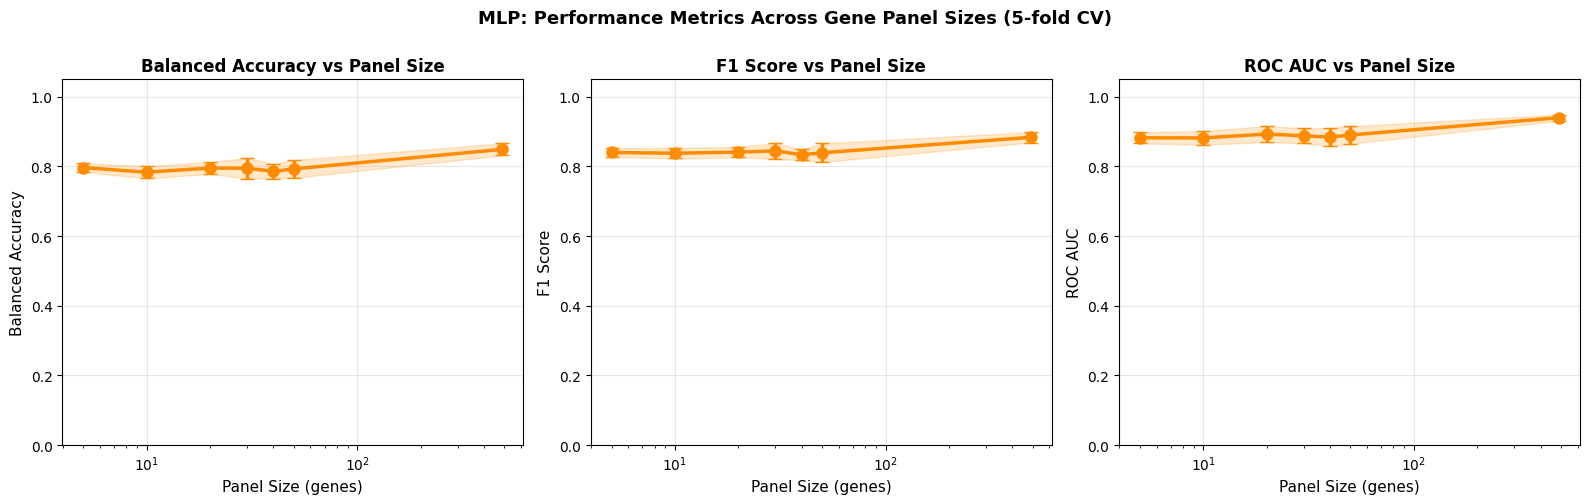

In [21]:
# Visualize performance across panel sizes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ['balanced_accuracy', 'f1', 'roc_auc']
metric_names = ['Balanced Accuracy', 'F1 Score', 'ROC AUC']

for ax, metric, name in zip(axes, metrics_to_plot, metric_names):
    means = []
    stds = []

    for k in ALL_SIZES:
        vals = [m[metric] for m in results[k]]
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    ax.errorbar(ALL_SIZES, means, yerr=stds, marker='o', capsize=5,
                linewidth=2.5, markersize=8, color='darkorange')
    ax.fill_between(ALL_SIZES,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.2, color='darkorange')

    ax.set_xlabel('Panel Size (genes)', fontsize=11)
    ax.set_ylabel(name, fontsize=11)
    ax.set_title(f'{name} vs Panel Size', fontsize=12, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.suptitle('MLP: Performance Metrics Across Gene Panel Sizes (5-fold CV)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('plots/mlp_performance_across_panels.png', dpi=150, bbox_inches='tight')
print("Plot saved to plots/mlp_performance_across_panels.png")
plt.show()

['brca1' 'brca2' 'palb2' 'pten' 'tp53' 'atm' 'cdh1' 'chek2' 'nbn' 'nf1'
 'stk11' 'bard1' 'mlh1' 'msh2' 'msh6' 'pms2' 'epcam' 'rad51c' 'rad51d'
 'rad50' 'rb1' 'rbl1' 'rbl2' 'ccna1' 'ccnb1' 'cdk1' 'ccne1' 'cdk2'
 'cdc25a' 'ccnd1' 'cdk4' 'cdk6' 'ccnd2' 'cdkn2a' 'cdkn2b' 'myc' 'cdkn1a'
 'cdkn1b' 'e2f1' 'e2f2' 'e2f3' 'e2f4' 'e2f5' 'e2f6' 'e2f7' 'e2f8' 'src'
 'jak1' 'jak2' 'stat1' 'stat2' 'stat3' 'stat5a' 'stat5b' 'mdm2' 'tp53bp1'
 'adam10' 'adam17' 'aph1a' 'aph1b' 'arrdc1' 'cir1' 'ctbp1' 'ctbp2' 'cul1'
 'dll1' 'dll3' 'dll4' 'dtx1' 'dtx2' 'dtx3' 'dtx4' 'ep300' 'fbxw7' 'hdac1'
 'hdac2' 'hes1' 'hes5' 'heyl' 'itch' 'jag1' 'jag2' 'kdm5a' 'lfng' 'maml1'
 'maml2' 'maml3' 'ncor2' 'ncstn' 'notch1' 'notch2' 'notch3' 'nrarp' 'numb'
 'numbl' 'psen1' 'psen2' 'psenen' 'rbpj' 'rbpjl' 'rfng' 'snw1' 'spen'
 'hes2' 'hes4' 'hes7' 'hey1' 'hey2' 'acvr1' 'acvr1b' 'acvr1c' 'acvr2a'
 'acvr2b' 'acvrl1' 'akt1' 'akt1s1' 'akt2' 'apaf1' 'arl11' 'atr' 'aurka'
 'bad' 'bcl2' 'bcl2l1' 'bmp10' 'bmp15' 'bmp2' 'bmp3' 'bmp4' '

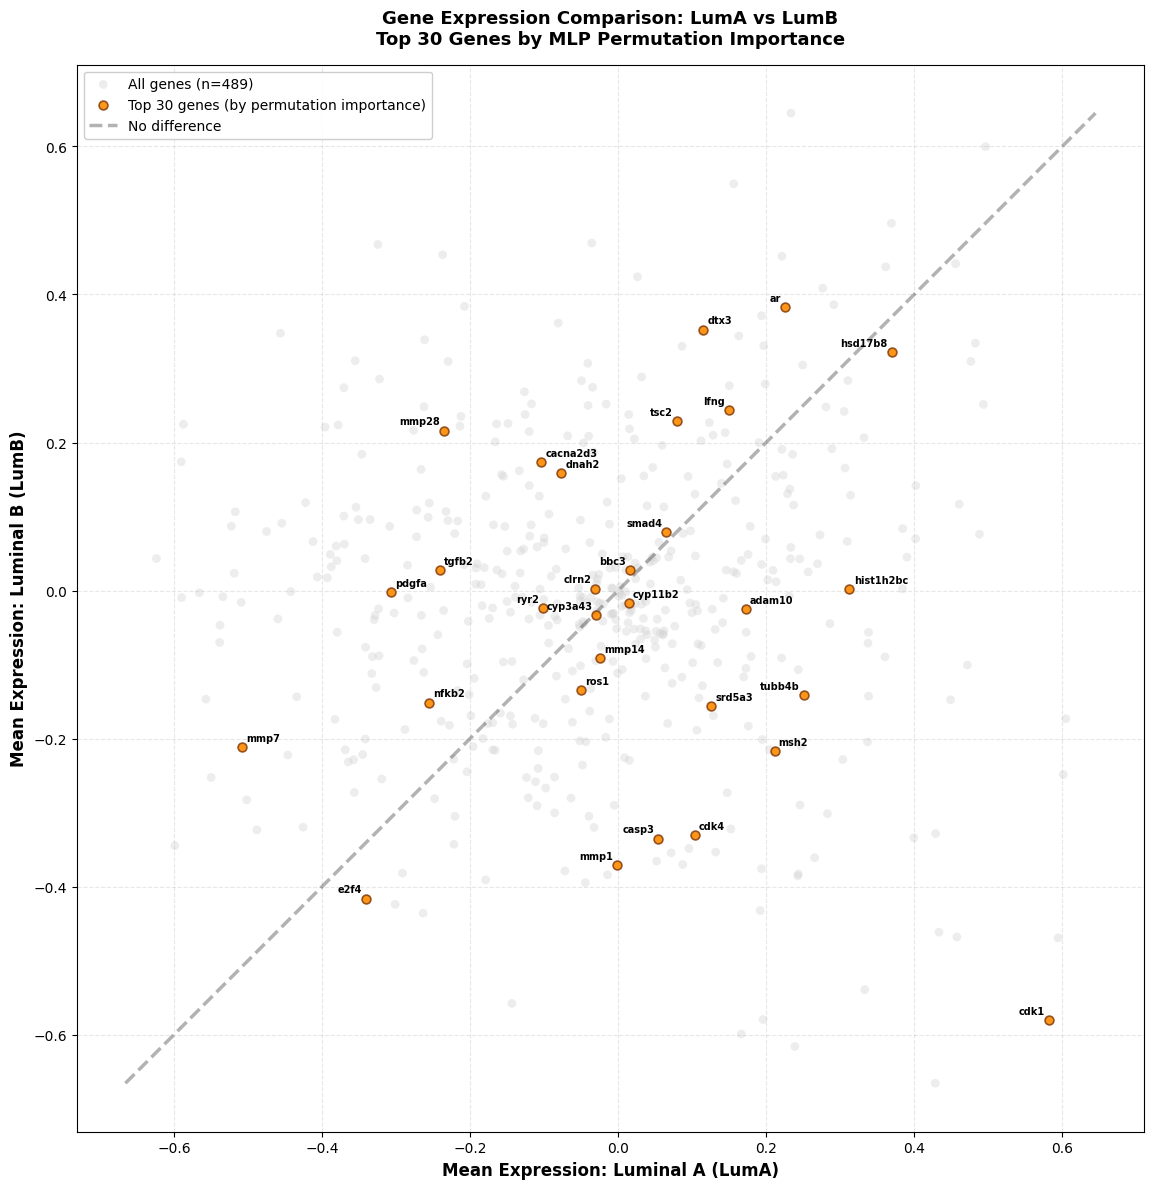


TOP 30 GENES BY MLP Importance

Rank   Gene Name            Gene Index   Perm Imp     LumA Mean     LumB Mean     Direction      
--------------------------------------------------------------------------------------------------------------


In [17]:
# Visualize top 30 genes by MLP permutation importance

try:
    df_temp = pd.read_csv(CSV, low_memory=False)
    gene_names = df_temp.columns[31:520].values
    print(gene_names)

except:
    gene_names = np.array([f'Gene_{i}' for i in range(489)])


X_np = X.values
y_np = y.values.astype(int)

luma_means = X_np[y_np == 0].mean(axis=0)
lumb_means = X_np[y_np == 1].mean(axis=0)

# already have importances from above
top_30_idx = np.argsort(importances)[-30:][::-1]

fig, ax = plt.subplots(figsize=(14, 12))

ax.scatter(luma_means, lumb_means,
          s=40, alpha=0.4, color='lightgray',
          edgecolors='none', label='All genes (n=489)', zorder=1)

ax.scatter(luma_means[top_30_idx], lumb_means[top_30_idx],
          s=40, alpha=0.9, color='darkorange',
          edgecolors='saddlebrown', linewidths=1.2,
          label='Top 30 genes (by permutation importance)', zorder=4)

for rank, gene_idx in enumerate(top_30_idx, 1):
    x_coord = luma_means[gene_idx]
    y_coord = lumb_means[gene_idx]
    gene_name = gene_names[gene_idx]

    if rank % 2 == 0:
        xytext = (3, 3)
        ha = 'left'
        va = 'bottom'
    else:
        xytext = (-3, 3)
        ha = 'right'
        va = 'bottom'

    ax.annotate(
        gene_name, xy=(x_coord, y_coord), xytext=xytext,
        textcoords='offset points', fontsize=7,
        fontweight='bold', color='black',
        ha=ha, va=va, zorder=5
    )

min_val = min(luma_means.min(), lumb_means.min())
max_val = max(luma_means.max(), lumb_means.max())
ax.plot([min_val, max_val], [min_val, max_val],
       'k--', alpha=0.3, linewidth=2.5,
       label='No difference', zorder=2)

ax.set_xlabel('Mean Expression: Luminal A (LumA)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Expression: Luminal B (LumB)', fontsize=12, fontweight='bold')
ax.set_title('Gene Expression Comparison: LumA vs LumB\nTop 30 Genes by MLP Permutation Importance',
            fontsize=13, fontweight='bold', pad=15)

ax.set_aspect('equal')
ax.grid(True, alpha=0.3, linestyle='--', zorder=0)
ax.legend(fontsize=10, loc='upper left', framealpha=0.95)

plt.tight_layout()
plt.savefig('plots/mlp_gene_scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 110)
print("TOP 30 GENES BY MLP Importance")
print("=" * 110)
print(f"\n{'Rank':<6} {'Gene Name':<20} {'Gene Index':<12} {'Perm Imp':<12} {'LumA Mean':<13} {'LumB Mean':<13} {'Direction':<15}")
print("-" * 110)

for rank, gene_idx in enumerate(top_30_idx, 1):
    gene_name = gene_names[gene_idx]
    gw = importances[gene_idx]
    luma_expr = luma_means[gene_idx]
    lumb_expr = lumb_means[gene_idx]
    difference = lumb_expr - luma_expr
    direction = "Higher in LumB" if difference > 0 else "Higher in LumA"

In [18]:
mlp_predictions = {}
y_pred = final_net.predict(X_test)
mlp_predictions[489] = {'y_true': y_test, 'y_pred': y_pred}

for search, arr, k in zip(searches, all_top_k_idx, FEATURE_COUNTS):
    X_test_k = X_test[:, arr]
    y_pred = search.predict(X_test_k)
    mlp_predictions[k] = {'y_true': y_test, 'y_pred': y_pred}

Saved: plots/mlp_confusion_matrices_with_gates.png


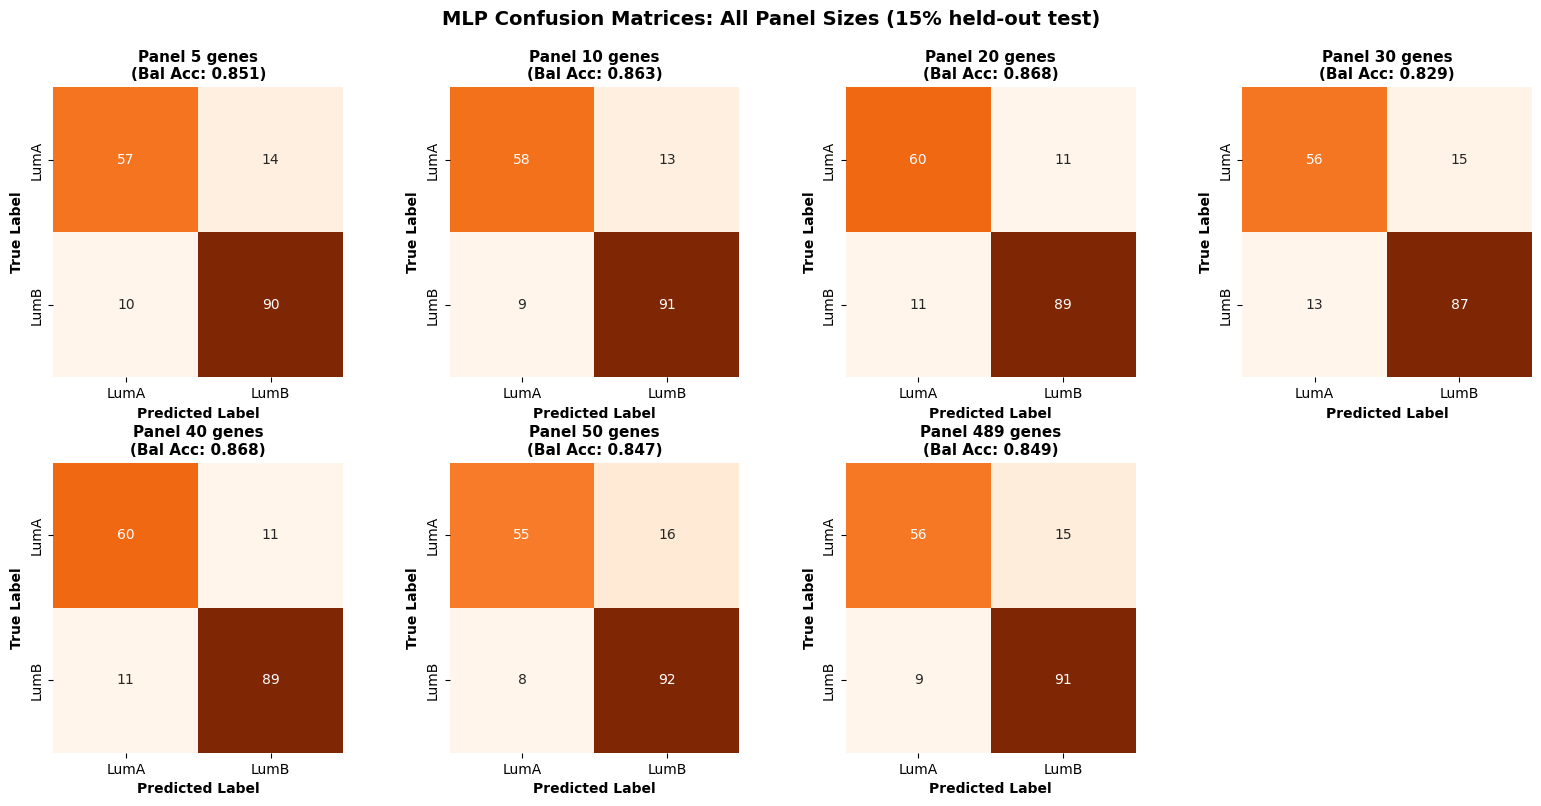

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, k in zip(axes, ALL_SIZES):
    r = mlp_predictions[k]
    cm = confusion_matrix(r['y_true'], r['y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Oranges',
                cbar=False, square=True,
                xticklabels=['LumA', 'LumB'],
                yticklabels=['LumA', 'LumB'])
    ba = balanced_accuracy_score(r['y_true'], r['y_pred'])
    ax.set_title(f'Panel {k} genes\n(Bal Acc: {ba:.3f})', fontweight='bold', fontsize=11)
    ax.set_ylabel('True Label', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=10)

for j in range(len(ALL_SIZES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('MLP Confusion Matrices: All Panel Sizes (15% held-out test)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('plots/mlp_confusion_matrices.png', dpi=150, bbox_inches='tight')
print("Saved: plots/mlp_confusion_matrices.png")
plt.show()

Saved: plots/mlp_feature_importances_with_gates.png


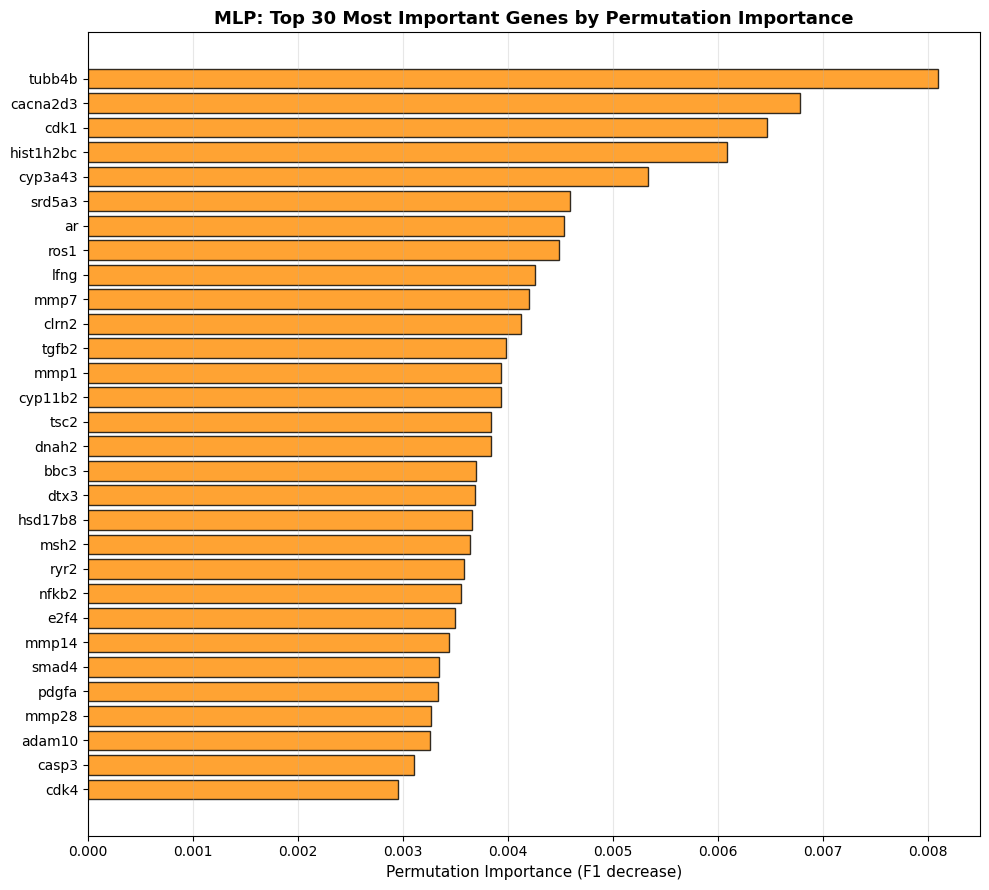


Top 30 genes by MLP Permutation Importance:
   1. tubb4b           0.0081
   2. cacna2d3         0.0068
   3. cdk1             0.0065
   4. hist1h2bc        0.0061
   5. cyp3a43          0.0053
   6. srd5a3           0.0046
   7. ar               0.0045
   8. ros1             0.0045
   9. lfng             0.0043
  10. mmp7             0.0042
  11. clrn2            0.0041
  12. tgfb2            0.0040
  13. mmp1             0.0039
  14. cyp11b2          0.0039
  15. tsc2             0.0038
  16. dnah2            0.0038
  17. bbc3             0.0037
  18. dtx3             0.0037
  19. hsd17b8          0.0037
  20. msh2             0.0036
  21. ryr2             0.0036
  22. nfkb2            0.0035
  23. e2f4             0.0035
  24. mmp14            0.0034
  25. smad4            0.0033
  26. pdgfa            0.0033
  27. mmp28            0.0033
  28. adam10           0.0033
  29. casp3            0.0031
  30. cdk4             0.0030


In [20]:
TOP_N = 30

# already have importances

top_idx = np.argsort(importances)[-TOP_N:][::-1]
feature_names = X.columns
top_names = feature_names[top_idx]
top_weights = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 9))
y_pos = np.arange(TOP_N)
ax.barh(y_pos, top_weights[::-1], color='darkorange', alpha=0.8, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel('Permutation Importance (F1 decrease)', fontsize=11)
ax.set_title(f'MLP: Top {TOP_N} Most Important Genes by Permutation Importance',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plots/mlp_feature_importances.png', dpi=150, bbox_inches='tight')
print("Saved: plots/mlp_feature_importances.png")
plt.show()

print(f"\nTop {TOP_N} genes by MLP Permutation Importance:")
for i, (name, wt) in enumerate(zip(top_names, top_weights), 1):
    print(f"  {i:2d}. {name:<15s}  {wt:.4f}")